In [14]:
%matplotlib inline

import os
import sys
import copy

import torch
import numpy as np

import matplotlib.pyplot as plt

sys.path.append('../../../')

%load_ext autoreload
%autoreload 2

from computer_vision.yolov11_pose.parameter_parser import parser
from computer_vision.yolov11_pose.nn.tasks import PoseModel
from computer_vision.yolov11.data.utils import imread
from computer_vision.yolov11.data.augment import LetterBox # for preprocessing
from computer_vision.yolov11_pose.utils.nms import non_max_suppression # for post processing
from computer_vision.yolov11_pose.utils.ops import scale_boxes, scale_coords
from computer_vision.yolov11_pose.engine.results import Results
from computer_vision.yolov11_pose.utils.viz import skeletons_overlay
from computer_vision.yolov11_pose.cfg import get_cfg

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
cfg='../yolo11-pose.yaml'
output_dirpath='D:/results/yolov11_pose/training'
checkpoint_dirpath=os.path.join(output_dirpath, 'checkpoints')
model=PoseModel(cfg=cfg,nc=1,verbose=True)
checkpoint_file=os.path.join(checkpoint_dirpath, 'best.pt')
assert os.path.isfile(checkpoint_file), f'{checkpoint_file} does not exist'
checkpoint=torch.load(checkpoint_file, weights_only=False)
model.load_state_dict(checkpoint['model'])

In nn.tasks.PoseModel.__init__ type(cfg) <class 'str'>, cfg ../yolo11-pose.yaml
In nn.tasks.parse_model d {'nc': 1, 'kpt_shape': [17, 3], 'scales': {'n': [0.5, 0.25, 1024], 's': [0.5, 0.5, 1024], 'm': [0.5, 1.0, 512], 'l': [1.0, 1.0, 512], 'x': [1.0, 1.5, 512]}, 'backbone': [[-1, 1, 'Conv', [64, 3, 2]], [-1, 1, 'Conv', [128, 3, 2]], [-1, 2, 'C3k2', [256, False, 0.25]], [-1, 1, 'Conv', [256, 3, 2]], [-1, 2, 'C3k2', [512, False, 0.25]], [-1, 1, 'Conv', [512, 3, 2]], [-1, 2, 'C3k2', [512, True]], [-1, 1, 'Conv', [1024, 3, 2]], [-1, 2, 'C3k2', [1024, True]], [-1, 1, 'SPPF', [1024, 5]], [-1, 2, 'C2PSA', [1024]]], 'head': [[-1, 1, 'nn.Upsample', ['None', 2, 'nearest']], [[-1, 6], 1, 'Concat', [1]], [-1, 2, 'C3k2', [512, False]], [-1, 1, 'nn.Upsample', ['None', 2, 'nearest']], [[-1, 4], 1, 'Concat', [1]], [-1, 2, 'C3k2', [256, False]], [-1, 1, 'Conv', [256, 3, 2]], [[-1, 13], 1, 'Concat', [1]], [-1, 2, 'C3k2', [512, False]], [-1, 1, 'Conv', [512, 3, 2]], [[-1, 10], 1, 'Concat', [1]], [-1, 2, 

<All keys matched successfully>

images  [(640, 480, 3), (429, 640, 3), (480, 640, 3)]


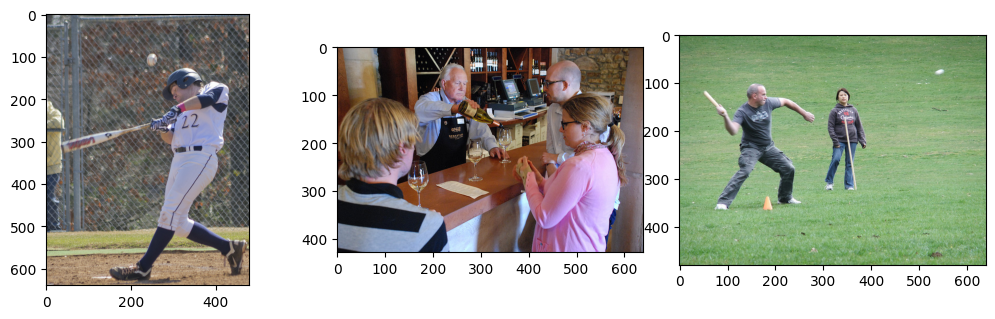

In [16]:
data_dirpath='D:/data/ultralytics/coco-pose/images/test2017'
img_files=['000000000016.jpg','000000000069.jpg','000000000063.jpg']
orig_imgs=[imread(os.path.join(data_dirpath, img_file)) for img_file in img_files if os.path.isfile(os.path.join(data_dirpath, img_file))] # HxWxC
print('images ', [im.shape for im in orig_imgs])
_, ax=plt.subplots(1,len(orig_imgs),figsize=(10,3))
for i, im in enumerate(orig_imgs): ax[i].imshow(im[...,::-1]) # BGR to RGB
plt.tight_layout(pad=0, w_pad=0, h_pad=0)

### Preprocessing

same_shape  False
imgs  [(640, 640, 3), (640, 640, 3), (640, 640, 3)]
imgs  torch.Size([3, 3, 640, 640]) 0.0 1.0


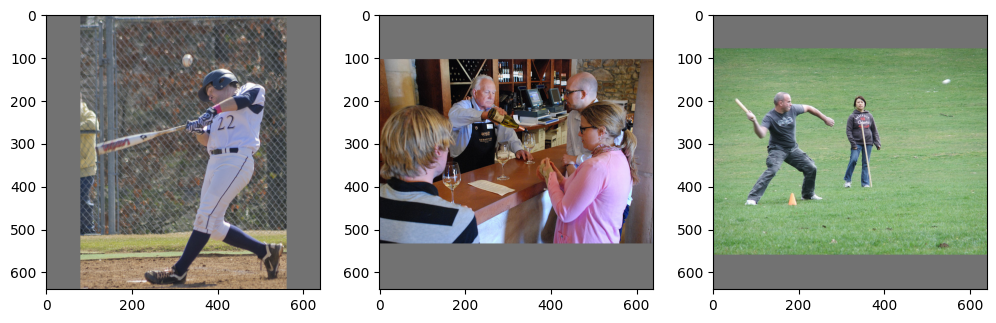

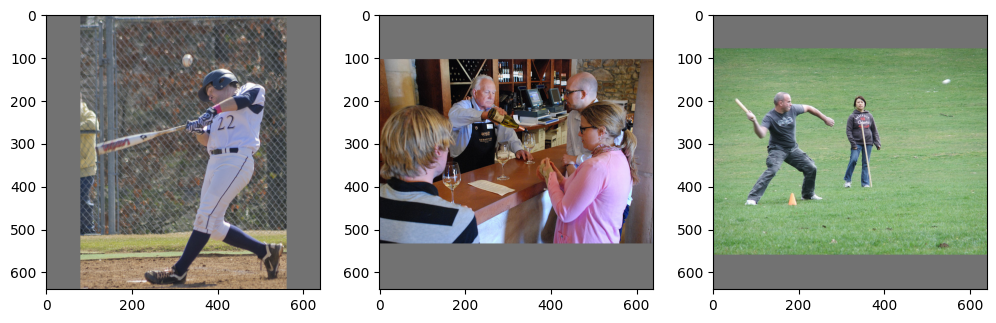

In [17]:
same_shape=len({x.shape for x in orig_imgs})==1
print('same_shape ', same_shape)

letterbox=LetterBox((640,640), auto=same_shape, stride=(8,16,32)) # stride is model strides
imgs=[letterbox(image=x) for x in orig_imgs]
print('imgs ', [i.shape for i in imgs])

# let's look at the image
_, ax=plt.subplots(1,len(imgs),figsize=(10,3))
for i, im in enumerate(imgs): ax[i].imshow(im[...,::-1]) # BGR to RGB
plt.tight_layout(pad=0, w_pad=0, h_pad=0)

# stack them to form batched image and normalized them
imgs=np.stack(imgs) # BGR BxHxWxC
imgs=imgs[...,::-1] # BGR to RGB
imgs=np.ascontiguousarray( imgs.transpose((0,3,1,2)) ) # BxHxWxC to BxCxHxW
imgs=torch.from_numpy(imgs)/255. # from 0-255 to 0-1
print('imgs ', imgs.shape, imgs.min().item(), imgs.max().item())

# let's look at the image
_, ax=plt.subplots(1,len(imgs),figsize=(10,3))
for i, im in enumerate(imgs): ax[i].imshow(im.permute(1,2,0).numpy()) 
plt.tight_layout(pad=0, w_pad=0, h_pad=0)

### Inference

In [18]:
model.eval()
with torch.no_grad(): preds=model(imgs)
print('preds ', type(preds), len(preds), [type(p) for p in preds], [p.shape if isinstance(p, torch.Tensor) else len(p) for p in preds])

preds  <class 'tuple'> 2 [<class 'torch.Tensor'>, <class 'tuple'>] [torch.Size([3, 56, 8400]), 2]


## Postprocessing

In [19]:
cfg=get_cfg()
if cfg.conf is None: cfg.conf=0.25
print(f'conf {cfg.conf}, iou {cfg.iou}, classes {cfg.classes}, agnostic_nms {cfg.agnostic_nms}, max_det {cfg.max_det}')
pred_outs=non_max_suppression(preds, conf_thres=cfg.conf, iou_thres=cfg.iou, classes=cfg.classes, 
                              agnostic=cfg.agnostic_nms, multi_label=False, max_det=cfg.max_det, 
                              nc=0 if cfg.task == "detect" else len(model.names), max_nms=30000, max_wh=7680, end2end= False, 
                              return_idxs= False)
print('pred_outs ', [p.shape for p in pred_outs])

conf 0.25, iou 0.7, classes None, agnostic_nms False, max_det 300
pred_outs  [torch.Size([1, 57]), torch.Size([5, 57]), torch.Size([2, 57])]


#### Visualize outcomes on input images

0

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


 --------------------
	conf tensor([0.8601]), class tensor([0.]),	pred_kpts.shape torch.Size([1, 17, 3]) 
		 313.409,176.471,0.470 	 520.580,585.073,0.532
1 --------------------
	conf tensor([0.8984, 0.8930, 0.8370, 0.3383, 0.2837]), class tensor([0., 0., 0., 0., 0.]),	pred_kpts.shape torch.Size([5, 17, 3]) 
		 -17.360,180.243,0.470 	 549.937,558.229,0.532
2 --------------------
	conf tensor([0.9082, 0.8745]), class tensor([0., 0.]),	pred_kpts.shape torch.Size([2, 17, 3]) 
		 81.968,203.681,0.470 	 383.061,425.677,0.532


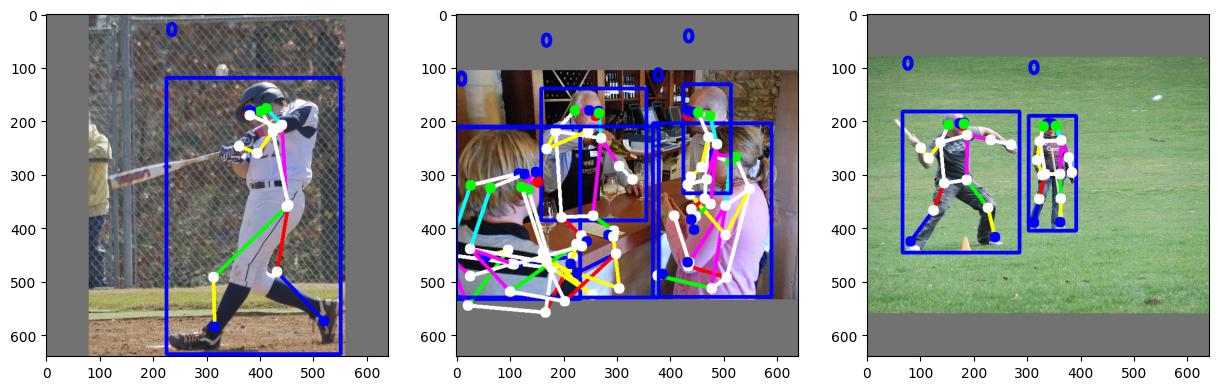

In [20]:
fig, ax=plt.subplots(1, len(pred_outs), figsize=(15,8))

for i, (pred_out, img) in enumerate(zip(pred_outs, imgs)):
    print(i, '-'*20)
    print(f'\tconf {pred_out[:,4]}, class {pred_out[:,5]}', end=',')
    # pred_out (B, 4 + 2 + 17*3) for bounding box, conf, cls, keypoints
    # img CxHxW in RGB format 
    img_arr=img.permute(1,2,0).contiguous().numpy()[:,:,::-1] # change to HWC in BGR
    result=Results(img_arr, names=model.names, boxes=pred_out[:,:6], path=None)
    pred_kpts=pred_out[:,6:].view(pred_out.shape[0],*model.yaml['kpt_shape']) # 51=17x3
    result.update(keypoints=pred_kpts)
    print(f'\tpred_kpts.shape {pred_kpts.shape} ')
    print('\t\t', ','.join(f'{x:.3f}' for x in pred_kpts.reshape(-1,3).min(0).values), '\t',
          ','.join(f'{x:.3f}' for x in pred_kpts.reshape(-1,3).max(0).values))
    
    out=skeletons_overlay(img_bgr=img_arr, results=result, show=False)
    ax[i].imshow(out[:,:,::-1])

#### Visualize outcome on original images

0 --------------------
	conf tensor([0.8601]), class tensor([0.]),	pred_kpts.shape torch.Size([1, 17, 3]) 
		 313.409,176.471,0.470 	 520.580,585.073,0.532
		 233.409,176.471,0.470 	 440.580,585.073,0.532
1 --------------------
	conf tensor([0.8984, 0.8930, 0.8370, 0.3383, 0.2837]), class tensor([0., 0., 0., 0., 0.]),	pred_kpts.shape torch.Size([5, 17, 3]) 
		 -17.360,180.243,0.470 	 549.937,558.229,0.532
		 0.000,74.743,0.470 	 549.937,429.000,0.532
2 --------------------
	conf tensor([0.9082, 0.8745]), class tensor([0., 0.]),	pred_kpts.shape torch.Size([2, 17, 3]) 
		 81.968,203.681,0.470 	 383.061,425.677,0.532
		 81.968,123.681,0.470 	 383.061,345.677,0.532


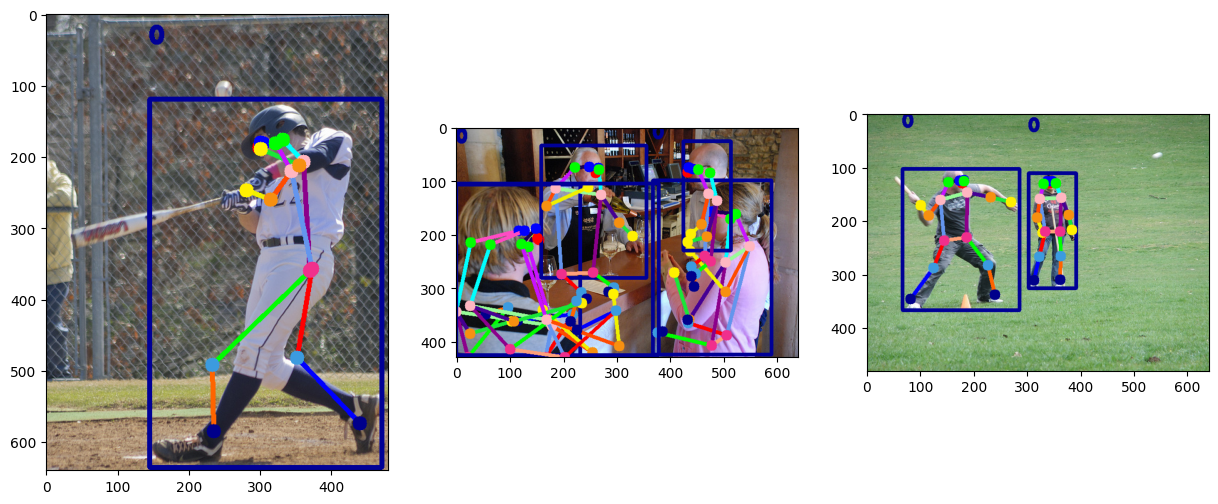

In [22]:
fig, ax=plt.subplots(1, len(pred_outs), figsize=(15,8))

for i, (pred, orig_img) in enumerate(zip(pred_outs, orig_imgs)):
    print(i, '-'*20)
    pred[:,:4]=scale_boxes(imgs.shape[2:], copy.deepcopy(pred[:,:4]), orig_img.shape[:-1])
    result=Results(orig_img, names=model.names, boxes=pred[:,:6], path=None)
    print(f'\tconf {pred[:,4]}, class {pred[:,5]}', end=',')
    # Extract keypoints from prediction and reshape according to model's keypoint shape
    pred_kpts=pred[:,6:].view(pred.shape[0],*model.yaml['kpt_shape']) # 51=17x3
    print(f'\tpred_kpts.shape {pred_kpts.shape} ')
    print('\t\t', ','.join(f'{x:.3f}' for x in pred_kpts.reshape(-1,3).min(0).values), '\t',
          ','.join(f'{x:.3f}' for x in pred_kpts.reshape(-1,3).max(0).values))
    # Scale keypoints coordinates to match the original image dimensions
    pred_kpts=scale_coords(imgs.shape[2:], pred_kpts, orig_img.shape)
    print('\t\t', ','.join(f'{x:.3f}' for x in pred_kpts.reshape(-1,3).min(0).values), '\t',
          ','.join(f'{x:.3f}' for x in pred_kpts.reshape(-1,3).max(0).values))
    result.update(keypoints=pred_kpts)
    
    out=skeletons_overlay(img_bgr=orig_img, results=result, show=False)
    ax[i].imshow(out[:,:,::-1])